In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize

# Stocks Selection

In [2]:
df = yf.download(tickers=["^GSPC","BRK-B","JPM","GS","LLY","XOM","TSM","ORCL","IBM","UBER","SAP"],end="2025-11-14",period="5y",interval="1mo",auto_adjust=True)
df = df['Close'].copy()

names_dict = dict()

for ticker in df.columns:
    names_dict[ticker] = yf.Ticker(ticker).info["longName"]

df.rename(columns=names_dict,inplace=True)
df.columns.name = "Company"
df.index.name = "Date"
df.sort_index(ascending=True,inplace=True)

print("No missing data") if not df.isna().any().any() else print("Data is missing")

[*********************100%***********************]  11 of 11 completed


No missing data


In [3]:
print(f"DataFrame's dimension: {df.shape}")
df.head()

DataFrame's dimension: (60, 11)


Company,Berkshire Hathaway Inc.,"The Goldman Sachs Group, Inc.",International Business Machines Corporation,JPMorgan Chase & Co.,Eli Lilly and Company,Oracle Corporation,SAP SE,Taiwan Semiconductor Manufacturing Company Limited,"Uber Technologies, Inc.",Exxon Mobil Corporation,S&P 500
Date,,,,,,,,,,,
2020-12-01,231.869995,232.905029,97.843643,111.602257,160.225601,60.339314,119.981956,99.847115,51.000000,33.689526,3756.070068
2021-01-01,227.869995,240.799026,92.581467,113.007492,197.359146,56.365822,116.126419,111.744453,50.930000,36.648193,3714.239990
2021-02-01,240.509995,283.698273,92.441551,130.186432,194.436295,60.401680,113.503922,115.808891,51.750000,44.437153,3811.149902
2021-03-01,255.470001,290.375946,104.964081,134.662506,178.028610,65.701210,112.988625,108.765076,54.509998,46.405327,3972.889893
2021-04-01,274.950012,310.639099,111.753708,136.060150,174.169174,70.963287,128.769669,107.753448,54.770000,47.577312,4181.169922


# Data Visualization

## Price

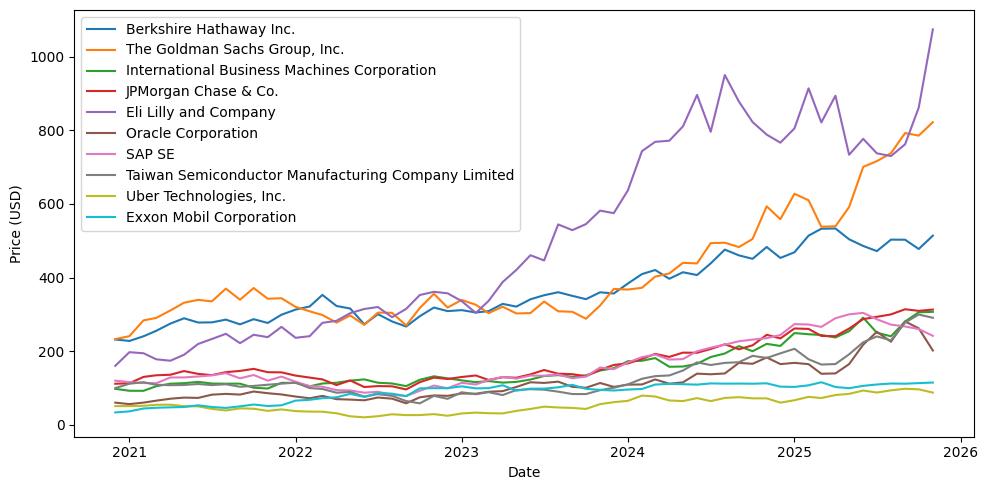

In [4]:
plt.figure(figsize=(10,5))
for stock in df.columns[:-1]:
    sns.lineplot(data=df,x="Date",y=stock,label=stock)
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Price Correlation and Distribution

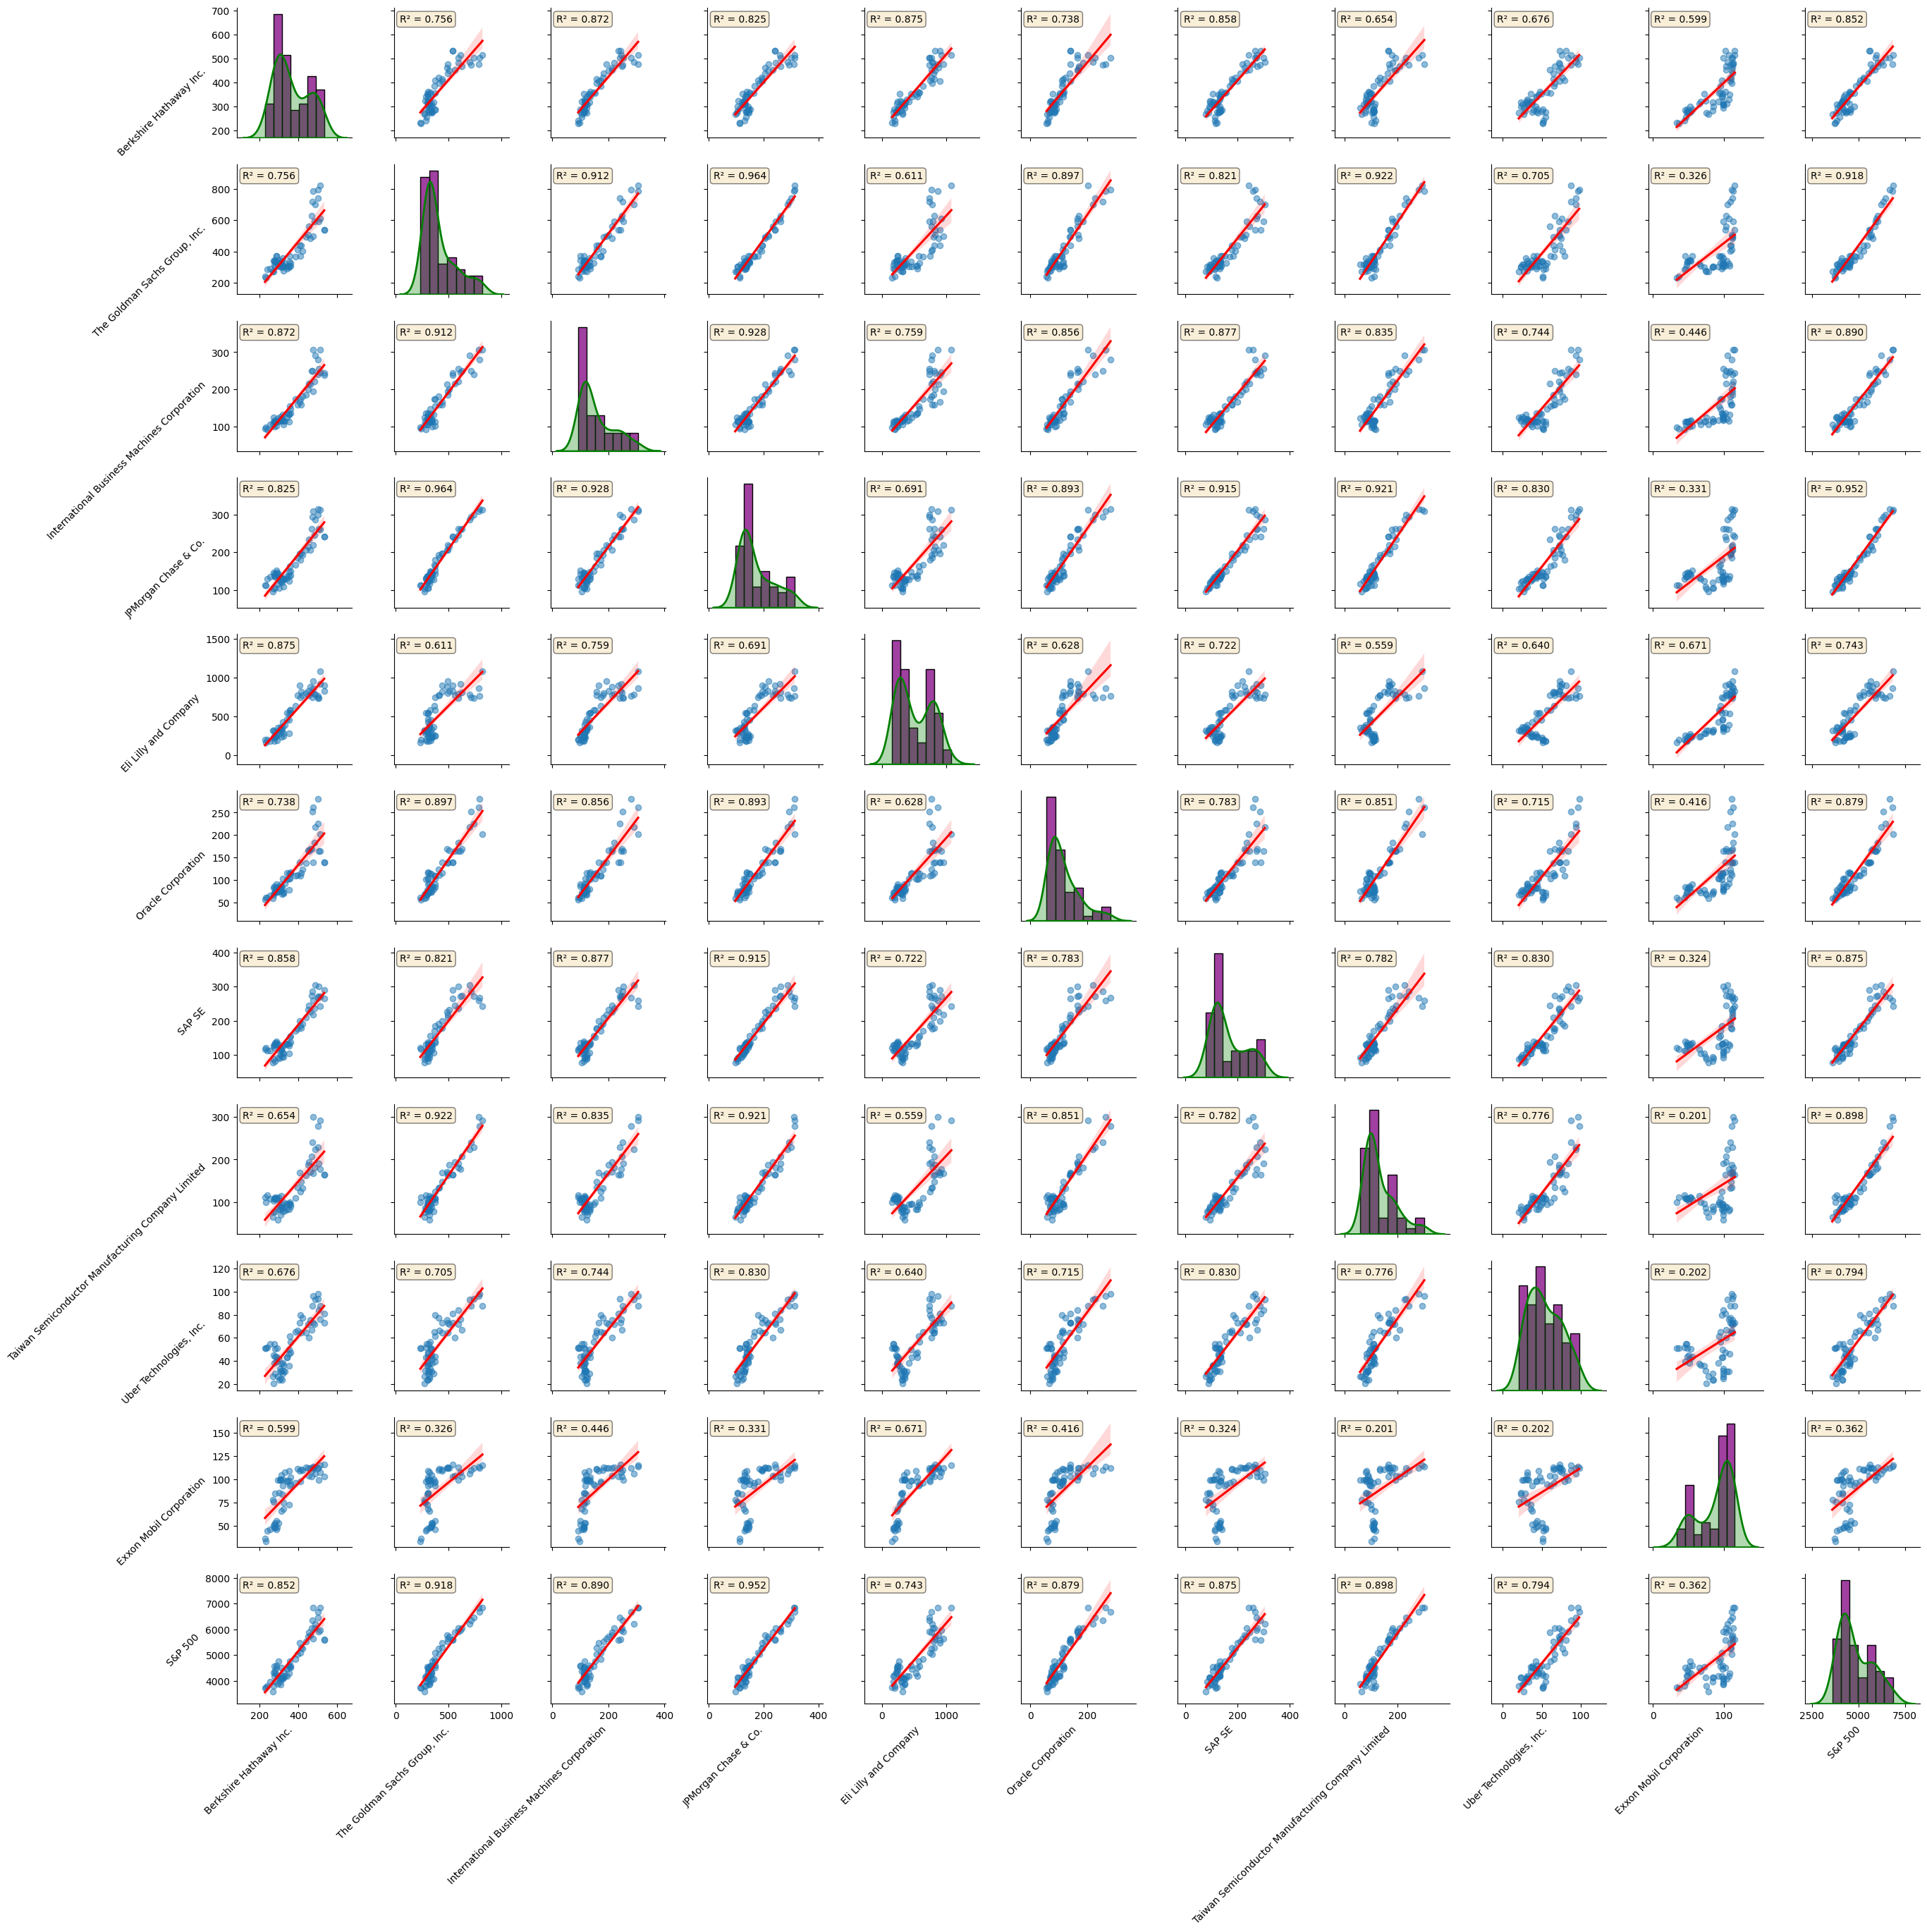

In [5]:
g = sns.PairGrid(df, diag_sharey=False)

def regplot_with_r2(x, y, **kwargs):
    ax = plt.gca()
    sns.regplot(x=x, y=y, scatter_kws={'alpha': 0.5}, line_kws={'color':"red"}, ax=ax)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r2 = r_value**2
    ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

def diag_plot(x, **kwargs):
    ax = plt.gca()
    sns.histplot(x, stat="density", kde=False, color="purple", ax=ax)
    sns.kdeplot(x, color="green", fill=True, alpha=0.3, linewidth=2, ax=ax)

g.map_upper(regplot_with_r2)
g.map_lower(regplot_with_r2)
g.map_diag(diag_plot)

for ax in g.axes[-1,:]:
    ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right') 
for ax in g.axes[:,0]:
    ax.set_ylabel(ax.get_ylabel(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Simple Percentage Yield

In [6]:
df_r = df.pct_change().dropna(axis="index").copy()
print(f"DataFrame's dimension: {df_r.shape}")
df_r.head()

DataFrame's dimension: (59, 11)


Company,Berkshire Hathaway Inc.,"The Goldman Sachs Group, Inc.",International Business Machines Corporation,JPMorgan Chase & Co.,Eli Lilly and Company,Oracle Corporation,SAP SE,Taiwan Semiconductor Manufacturing Company Limited,"Uber Technologies, Inc.",Exxon Mobil Corporation,S&P 500
Date,,,,,,,,,,,
2021-01-01,-0.017251,0.033894,-0.053781,0.012591,0.231758,-0.065852,-0.032134,0.119156,-0.001373,0.087822,-0.011137
2021-02-01,0.055470,0.178154,-0.001511,0.152016,-0.014810,0.071601,-0.022583,0.036373,0.016101,0.212533,0.026091
2021-03-01,0.062201,0.023538,0.135464,0.034382,-0.084386,0.087738,-0.004540,-0.060823,0.053333,0.044291,0.042439
2021-04-01,0.076252,0.069782,0.064685,0.010379,-0.021679,0.080091,0.139669,-0.009301,0.004770,0.025255,0.052425
2021-05-01,0.052700,0.067642,0.013110,0.074100,0.092849,0.043419,-0.000072,0.005311,-0.071937,0.019741,0.005486


# 1. Average Monthly Returns

In [7]:
average_vector = df_r.drop(columns="S&P 500").mean()
average_vector.apply(lambda decimal : f"{100*decimal:.6f} [%]")

Company
Berkshire Hathaway Inc.                               1.506637 [%]
The Goldman Sachs Group, Inc.                         2.463522 [%]
International Business Machines Corporation           2.213305 [%]
JPMorgan Chase & Co.                                  2.002325 [%]
Eli Lilly and Company                                 3.703517 [%]
Oracle Corporation                                    2.645574 [%]
SAP SE                                                1.466839 [%]
Taiwan Semiconductor Manufacturing Company Limited    2.305913 [%]
Uber Technologies, Inc.                               1.570434 [%]
Exxon Mobil Corporation                               2.387611 [%]
dtype: object

## 2.1 Average Variance of Monthly Returns

It should be noted that the population variance is used for the portfolio calculation. Since the **pandas** library defines the denominator of the variance calculation as **n-ddof**, where **ddof** represents the **"delta degrees of freedom"**, **ddof = 0** must be defined to obtain the population variance.

In [8]:
variance_vector = df_r.drop(columns="S&P 500").var(ddof=0)
variance_vector.apply(lambda decimal : f"{(decimal*100**2):.6f} [%^2]")

Company
Berkshire Hathaway Inc.                                29.846967 [%^2]
The Goldman Sachs Group, Inc.                          62.422497 [%^2]
International Business Machines Corporation            52.592574 [%^2]
JPMorgan Chase & Co.                                   48.525429 [%^2]
Eli Lilly and Company                                  88.132397 [%^2]
Oracle Corporation                                    119.593105 [%^2]
SAP SE                                                 56.032365 [%^2]
Taiwan Semiconductor Manufacturing Company Limited    100.442279 [%^2]
Uber Technologies, Inc.                               132.848502 [%^2]
Exxon Mobil Corporation                                60.254602 [%^2]
dtype: object

# 2.2 Standard Deviation of Monthly Returns

It should be noted that the population standard deviation is used to calculate the portfolio. This is done using the same process as for calculating the population variance with the **pandas** library.

In [9]:
std_vector = df_r.drop(columns="S&P 500").std(ddof=0)
std_vector.apply(lambda decimal : f"{100*decimal:.6f} [%]")

Company
Berkshire Hathaway Inc.                                5.463238 [%]
The Goldman Sachs Group, Inc.                          7.900791 [%]
International Business Machines Corporation            7.252074 [%]
JPMorgan Chase & Co.                                   6.966020 [%]
Eli Lilly and Company                                  9.387886 [%]
Oracle Corporation                                    10.935863 [%]
SAP SE                                                 7.485477 [%]
Taiwan Semiconductor Manufacturing Company Limited    10.022090 [%]
Uber Technologies, Inc.                               11.525992 [%]
Exxon Mobil Corporation                                7.762384 [%]
dtype: object

# 3.1 Variance-Covariance Matrix of Monthly Returns

In [10]:
cov_matrix_generalized = df_r.cov(ddof=0).copy()
cov_matrix = cov_matrix_generalized.iloc[:-1,:-1].copy() # S&P500 is removed for posterior analysis
cov_matrix

Company,Berkshire Hathaway Inc.,"The Goldman Sachs Group, Inc.",International Business Machines Corporation,JPMorgan Chase & Co.,Eli Lilly and Company,Oracle Corporation,SAP SE,Taiwan Semiconductor Manufacturing Company Limited,"Uber Technologies, Inc.",Exxon Mobil Corporation
Company,,,,,,,,,,
Berkshire Hathaway Inc.,0.002985,0.001774,0.001030,0.001854,0.001408,0.001042,0.001872,0.000282,0.001684,0.001733
"The Goldman Sachs Group, Inc.",0.001774,0.006242,0.001977,0.004682,-0.000105,0.003981,0.002586,0.003182,0.002211,0.001975
International Business Machines Corporation,0.001030,0.001977,0.005259,0.001815,0.000505,0.003318,0.002358,0.001496,0.002021,0.000452
JPMorgan Chase & Co.,0.001854,0.004682,0.001815,0.004853,-0.000045,0.003392,0.002359,0.002577,0.002830,0.001763
Eli Lilly and Company,0.001408,-0.000105,0.000505,-0.000045,0.008813,-0.000175,0.001720,0.000276,0.000350,0.000176
Oracle Corporation,0.001042,0.003981,0.003318,0.003392,-0.000175,0.011959,0.004134,0.004832,0.004053,0.001284
SAP SE,0.001872,0.002586,0.002358,0.002359,0.001720,0.004134,0.005603,0.003262,0.003294,0.000203
Taiwan Semiconductor Manufacturing Company Limited,0.000282,0.003182,0.001496,0.002577,0.000276,0.004832,0.003262,0.010044,0.004449,-0.000525
"Uber Technologies, Inc.",0.001684,0.002211,0.002021,0.002830,0.000350,0.004053,0.003294,0.004449,0.013285,-0.000510


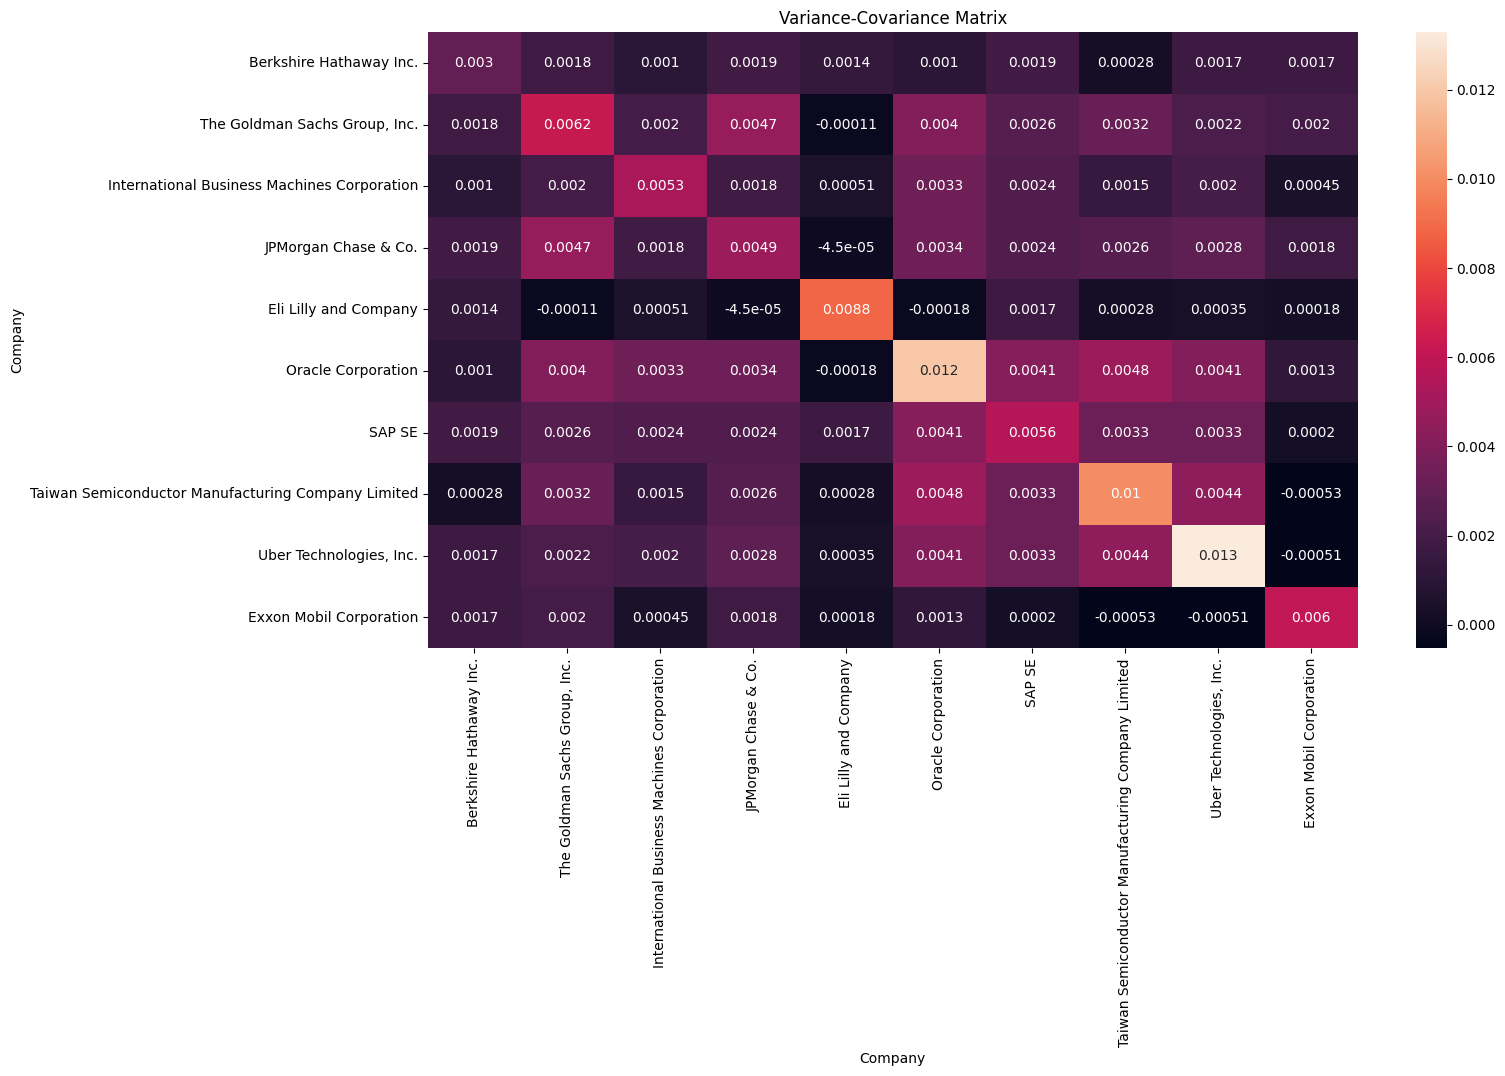

In [11]:
plt.figure(figsize=(15,8))
sns.heatmap(cov_matrix,annot=True)
plt.title("Variance-Covariance Matrix")
plt.show()

# 3.2 Matrix of Correlation Coefficients of Monthly Returns

In [12]:
corr_matrix = df_r.drop(columns="S&P 500").corr(method='pearson').copy()
corr_matrix

Company,Berkshire Hathaway Inc.,"The Goldman Sachs Group, Inc.",International Business Machines Corporation,JPMorgan Chase & Co.,Eli Lilly and Company,Oracle Corporation,SAP SE,Taiwan Semiconductor Manufacturing Company Limited,"Uber Technologies, Inc.",Exxon Mobil Corporation
Company,,,,,,,,,,
Berkshire Hathaway Inc.,1.000000,0.411025,0.259938,0.487200,0.274593,0.174382,0.457845,0.051428,0.267370,0.408668
"The Goldman Sachs Group, Inc.",0.411025,1.000000,0.344980,0.850609,-0.014216,0.460696,0.437282,0.401888,0.242803,0.322049
International Business Machines Corporation,0.259938,0.344980,1.000000,0.359286,0.074248,0.418408,0.434378,0.205810,0.241819,0.080356
JPMorgan Chase & Co.,0.487200,0.850609,0.359286,1.000000,-0.006932,0.445238,0.452485,0.369053,0.352494,0.326095
Eli Lilly and Company,0.274593,-0.014216,0.074248,-0.006932,1.000000,-0.017071,0.244708,0.029321,0.032348,0.024176
Oracle Corporation,0.174382,0.460696,0.418408,0.445238,-0.017071,1.000000,0.505041,0.440865,0.321541,0.151213
SAP SE,0.457845,0.437282,0.434378,0.452485,0.244708,0.505041,1.000000,0.434765,0.381796,0.034862
Taiwan Semiconductor Manufacturing Company Limited,0.051428,0.401888,0.205810,0.369053,0.029321,0.440865,0.434765,1.000000,0.385105,-0.067525
"Uber Technologies, Inc.",0.267370,0.242803,0.241819,0.352494,0.032348,0.321541,0.381796,0.385105,1.000000,-0.056987


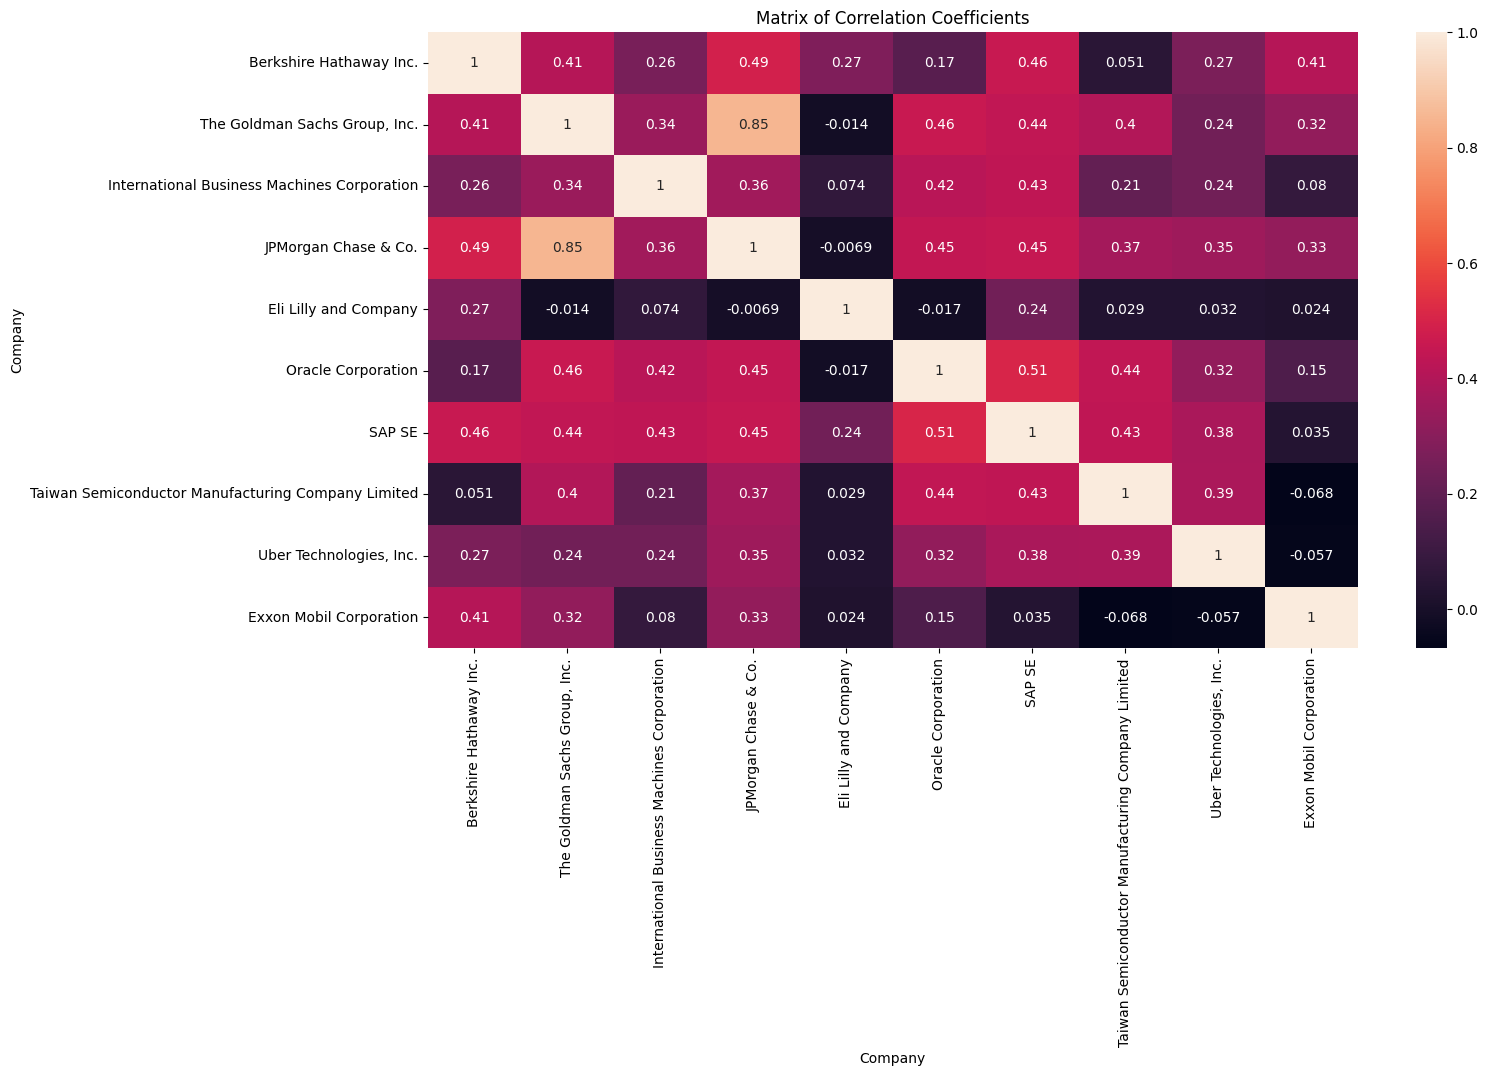

In [13]:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,annot=True)
plt.title("Matrix of Correlation Coefficients")
plt.show()

# 4. S&P 500 Statistics

In [14]:
sp_500_stats = df_r["S&P 500"].agg(mean="mean", var=lambda values : values.var(ddof=0), std=lambda values : values.std(ddof=0)).rename(index={"mean":"Average","var":"Variance","std":"Standard Deviation"})
for stat in sp_500_stats.index:
    print(f"{stat:<25} {sp_500_stats[stat]*100:.6f} [%]") if stat != "Varianza" else print(f"{stat:<25} {sp_500_stats[stat]*100**2:.6f} [%^2]")

Average                   1.118600 [%]
Variance                  0.189439 [%]
Standard Deviation        4.352460 [%]


# 5. Generation of Portfolios with Random Participations

To generate the weights randomly, we use the Dirichlet distribution, which, by definition, guarantees that the sum of all generated weights will equal 1. The definition can be found at https://en.wikipedia.org/wiki/Dirichlet_distribution.

In [15]:
np.random.seed(42) # To guarantee reproducibility
number_portfolios = 10000 #Be careful with resources consumption
weights_portfolios = pd.DataFrame(np.random.dirichlet(alpha=np.ones(df_r.drop(columns="S&P 500").shape[1]),size=number_portfolios), columns=df.drop(columns="S&P 500").columns)
weights_portfolios

Company,Berkshire Hathaway Inc.,"The Goldman Sachs Group, Inc.",International Business Machines Corporation,JPMorgan Chase & Co.,Eli Lilly and Company,Oracle Corporation,SAP SE,Taiwan Semiconductor Manufacturing Company Limited,"Uber Technologies, Inc.",Exxon Mobil Corporation
0,0.045694,0.293107,0.128217,0.088897,0.016517,0.016514,0.005827,0.195841,0.089495,0.119892
1,0.002610,0.439637,0.224167,0.029951,0.025182,0.025424,0.045519,0.093350,0.070965,0.043194
2,0.159453,0.025313,0.058216,0.076878,0.102599,0.259125,0.037529,0.121654,0.151220,0.008014
3,0.082154,0.016422,0.005908,0.261191,0.296056,0.145131,0.031909,0.009027,0.101251,0.050952
4,0.019316,0.101445,0.005193,0.356246,0.044442,0.161211,0.055438,0.108949,0.117425,0.030333
...,...,...,...,...,...,...,...,...,...,...
9995,0.021036,0.051745,0.094613,0.292410,0.274831,0.051273,0.082097,0.011160,0.087078,0.033757
9996,0.222434,0.145655,0.015923,0.059564,0.280484,0.046661,0.052460,0.036876,0.059824,0.080119
9997,0.007499,0.007725,0.116589,0.323034,0.053766,0.157211,0.161693,0.036704,0.031726,0.104053
9998,0.237139,0.188768,0.037786,0.043085,0.130929,0.037515,0.187680,0.069936,0.034016,0.033145


In [16]:
weights_portfolios_t = weights_portfolios.transpose()
weights_portfolios_t

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
Company,,,,,,,,,,,,,,,,,,,,,
Berkshire Hathaway Inc.,0.045694,0.002610,0.159453,0.082154,0.019316,0.245051,0.047730,0.183823,0.212854,0.017635,...,0.089064,0.111925,0.031162,0.047520,0.012280,0.021036,0.222434,0.007499,0.237139,0.126268
"The Goldman Sachs Group, Inc.",0.293107,0.439637,0.025313,0.016422,0.101445,0.104694,0.030702,0.027526,0.104504,0.172940,...,0.125999,0.017653,0.037215,0.230880,0.001750,0.051745,0.145655,0.007725,0.188768,0.010973
International Business Machines Corporation,0.128217,0.224167,0.058216,0.005908,0.005193,0.196802,0.171139,0.000688,0.043011,0.198036,...,0.163587,0.099826,0.248165,0.080148,0.365733,0.094613,0.015923,0.116589,0.037786,0.221455
JPMorgan Chase & Co.,0.088897,0.029951,0.076878,0.261191,0.356246,0.158008,0.042793,0.209967,0.007029,0.114066,...,0.061759,0.213130,0.165413,0.088443,0.078626,0.292410,0.059564,0.323034,0.043085,0.043965
Eli Lilly and Company,0.016517,0.025182,0.102599,0.296056,0.044442,0.063918,0.031986,0.152465,0.039872,0.204058,...,0.029619,0.022194,0.085813,0.038041,0.047297,0.274831,0.280484,0.053766,0.130929,0.153070
Oracle Corporation,0.016514,0.025424,0.259125,0.145131,0.161211,0.178865,0.075883,0.162226,0.042101,0.094258,...,0.175209,0.152281,0.046177,0.291866,0.030653,0.051273,0.046661,0.157211,0.037515,0.129525
SAP SE,0.005827,0.045519,0.037529,0.031909,0.055438,0.006501,0.014732,0.183293,0.139997,0.102408,...,0.101337,0.030525,0.190770,0.040639,0.005653,0.082097,0.052460,0.161693,0.187680,0.124502
Taiwan Semiconductor Manufacturing Company Limited,0.195841,0.093350,0.121654,0.009027,0.108949,0.015304,0.157165,0.009558,0.108635,0.077229,...,0.010314,0.057627,0.100546,0.000937,0.078195,0.011160,0.036876,0.036704,0.069936,0.092486
"Uber Technologies, Inc.",0.089495,0.070965,0.151220,0.101251,0.117425,0.003247,0.007514,0.055153,0.233591,0.003565,...,0.133736,0.070204,0.048762,0.125601,0.034731,0.087078,0.059824,0.031726,0.034016,0.057032


The variance of a portfolio is calculated using the following matrix equation:
$$\sigma^2_p = w^T\Sigma w$$
Since we have a matrix of weight vectors instead of each individual vector $(W)$, we simply replace the weight vectors in the equation with the weight matrices, and it should be noted that the variance results for each portfolio will be located on the diagonal of the resulting matrix:
$$\overrightarrow{\sigma^2_p} = diag(W^T\Sigma W)$$
Although it is possible to obtain the same results by iterating over each vector in the array of vectors, this is very inefficient compared to the vectorized operations that the **pandas** and **numpy** libraries use by default.

In [17]:
variances_portfolios = pd.Series(np.diag(weights_portfolios @ cov_matrix @ weights_portfolios_t))
variances_portfolios

0       0.002993
1       0.003303
2       0.003344
3       0.002616
4       0.003612
          ...   
9995    0.002493
9996    0.002242
9997    0.002891
9998    0.002354
9999    0.002449
Length: 10000, dtype: float64

In [18]:
risks_portfolios = variances_portfolios.apply(lambda number : np.sqrt(number))
risks_portfolios

0       0.054709
1       0.057469
2       0.057824
3       0.051142
4       0.060097
          ...   
9995    0.049931
9996    0.047353
9997    0.053769
9998    0.048513
9999    0.049484
Length: 10000, dtype: float64

To calculate the weighted return, matrix multiplication is used again, since there is a weight matrix and a vector of average returns; thus, the weighted return vector for each portfolio is calculated as follows:
$$\overrightarrow{R_p} = W\mu$$

In [19]:
weighted_returns = weights_portfolios @ average_vector
weighted_returns

0       0.022445
1       0.023002
2       0.022431
3       0.025290
4       0.021843
          ...   
9995    0.024711
9996    0.024579
9997    0.021703
9998    0.021455
9999    0.022877
Length: 10000, dtype: float64

In [20]:
summary_portfolio = pd.concat([weights_portfolios,weighted_returns,risks_portfolios],axis="columns").rename(columns={0:"Return",1:"Risk"})
summary_portfolio

,Berkshire Hathaway Inc.,"The Goldman Sachs Group, Inc.",International Business Machines Corporation,JPMorgan Chase & Co.,Eli Lilly and Company,Oracle Corporation,SAP SE,Taiwan Semiconductor Manufacturing Company Limited,"Uber Technologies, Inc.",Exxon Mobil Corporation,Return,Risk
0,0.045694,0.293107,0.128217,0.088897,0.016517,0.016514,0.005827,0.195841,0.089495,0.119892,0.022445,0.054709
1,0.002610,0.439637,0.224167,0.029951,0.025182,0.025424,0.045519,0.093350,0.070965,0.043194,0.023002,0.057469
2,0.159453,0.025313,0.058216,0.076878,0.102599,0.259125,0.037529,0.121654,0.151220,0.008014,0.022431,0.057824
3,0.082154,0.016422,0.005908,0.261191,0.296056,0.145131,0.031909,0.009027,0.101251,0.050952,0.025290,0.051142
4,0.019316,0.101445,0.005193,0.356246,0.044442,0.161211,0.055438,0.108949,0.117425,0.030333,0.021843,0.060097
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.021036,0.051745,0.094613,0.292410,0.274831,0.051273,0.082097,0.011160,0.087078,0.033757,0.024711,0.049931
9996,0.222434,0.145655,0.015923,0.059564,0.280484,0.046661,0.052460,0.036876,0.059824,0.080119,0.024579,0.047353
9997,0.007499,0.007725,0.116589,0.323034,0.053766,0.157211,0.161693,0.036704,0.031726,0.104053,0.021703,0.053769
9998,0.237139,0.188768,0.037786,0.043085,0.130929,0.037515,0.187680,0.069936,0.034016,0.033145,0.021455,0.048513


# 6. Portfolio Chart

It was observed that for 1000 portfolios with 10 stocks each, it was very difficult to observe the efficient frontier. The greater the number of stocks in a portfolio, the higher the density of points on the chart needed to observe the efficient frontier. Therefore, it was decided to increase the number of portfolios to 10000, which is what is shown in the chart below:

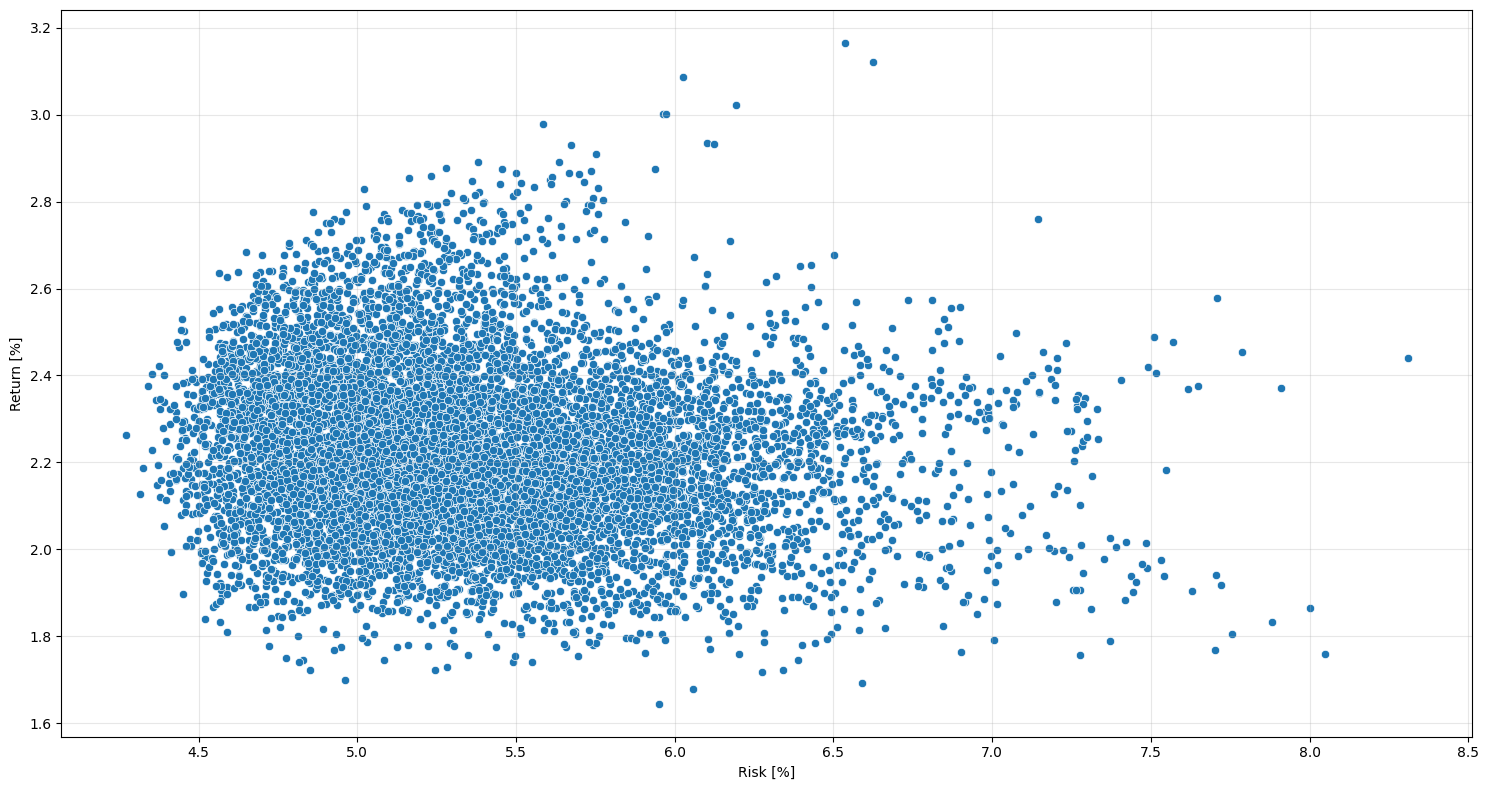

In [21]:
plt.figure(figsize=(15,8))
sns.scatterplot(x=summary_portfolio["Risk"]*100,y=summary_portfolio["Return"]*100)
plt.xlabel("Risk [%]")
plt.ylabel("Return [%]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The efficient frontier can be easily visualized in the previous chart.

# 7. Calculation of the minimum variance portfolio

## Optimization Problem

Calculating the minimum variance portfolio is a constrained optimization problem. It is an optimization problem because it seeks to find the weights assigned to each stock that minimize the portfolio's variance, and it is a constrained problem because the search space $(R^{10})$ has the restriction that its components must sum to 1, and furthermore, to **avoid** obtaining "trivial" or "unbalanced" results, we can impose the restriction of a minimum value on each component (which means imposing a minimum stake on each stock).

There are a wide variety of methods for solving this type of optimization problem. In this case, the **scipy** library is used, more specifically the **minimize** method from the **optimize** module. There are different optimization algorithms for finding the minima of a function; in this case, a standard algorithm for this type of problem is used: **SLSQP**.

For more information on how does the library work, check the following link: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

In [35]:
# Objective funtion: Portfolio Variance
def portfolio_variance(weights, matriz_covarianzas):
    return weights.transpose() @ matriz_covarianzas @ weights

# Limits and restrictions
restrictions = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Weights sum = 1
limits = tuple((0.05, 1) for _ in range(len(cov_matrix)))  # Weights between 5% and 100%
limits_no_restriction = tuple((0, 1) for _ in range(len(cov_matrix)))  # Weights between 0% and 100%

# Initial Conditions
w0 = np.ones(len(cov_matrix)) / len(cov_matrix)

# Optimization
result = optimize.minimize(
    portfolio_variance,
    w0,
    args=(cov_matrix),
    method='SLSQP',
    bounds=limits,
    constraints=restrictions,
    options={'ftol':1e-8} #Precision improvement to meet conditions
)
result_no_restrictions = optimize.minimize(
    portfolio_variance,
    w0,
    args=(cov_matrix),
    method='SLSQP',
    bounds=limits_no_restriction,
    constraints=restrictions,
    options={'ftol':1e-12}
)

optimized_weights = pd.Series(result.x, index=df.drop(columns="S&P 500").columns)
optimized_weights_no_restrictions = pd.Series(result_no_restrictions.x, index=df.drop(columns="S&P 500").columns)
print(f"Optimized Weights' Vector\n{optimized_weights}")
print(f"Weights' Sum: {optimized_weights.sum()}\n")
print(f"Optimized Weights' Vector - No Restrictions\n{optimized_weights_no_restrictions}")
print(f"Weights' Sum - No Restrictions: {optimized_weights_no_restrictions.sum()}")

Optimized Weights' Vector
Company
Berkshire Hathaway Inc.                               0.231460
The Goldman Sachs Group, Inc.                         0.050000
International Business Machines Corporation           0.136739
JPMorgan Chase & Co.                                  0.050000
Eli Lilly and Company                                 0.140489
Oracle Corporation                                    0.050000
SAP SE                                                0.050000
Taiwan Semiconductor Manufacturing Company Limited    0.063263
Uber Technologies, Inc.                               0.050000
Exxon Mobil Corporation                               0.178049
dtype: float64
Weights' Sum: 1.0

Optimized Weights' Vector - No Restrictions
Company
Berkshire Hathaway Inc.                               3.156275e-01
The Goldman Sachs Group, Inc.                         4.319868e-18
International Business Machines Corporation           1.924751e-01
JPMorgan Chase & Co.                             

In [36]:
variance_portfolio_min_var = optimized_weights.transpose() @ cov_matrix @ optimized_weights
risk_portfolio_min_var = np.sqrt(variance_portfolio_min_var)
return_min_var = optimized_weights @ average_vector
print(f"Minimum Risk: {risk_portfolio_min_var*100:.6f} [%]")
print(f"Return for Minimum Risk: {return_min_var*100:.6f} [%]\n")

variance_portfolio_min_var_no_restrictions = optimized_weights_no_restrictions.transpose() @ cov_matrix @ optimized_weights_no_restrictions
risk_portfolio_min_var_no_restrictions = np.sqrt(variance_portfolio_min_var_no_restrictions)
return_min_var_no_restrictions = optimized_weights_no_restrictions @ average_vector
print(f"Minimum Risk - No Restrictions: {risk_portfolio_min_var_no_restrictions*100:.6f} [%]")
print(f"Return for Minimum Risk - No Restrictions: {return_min_var_no_restrictions*100:.6f} [%]")

Minimum Risk: 4.341277 [%]
Return for Minimum Risk: 2.250101 [%]

Minimum Risk - No Restrictions: 4.199269 [%]
Return for Minimum Risk - No Restrictions: 2.212363 [%]


## Minimum Variance Portfolio Chart

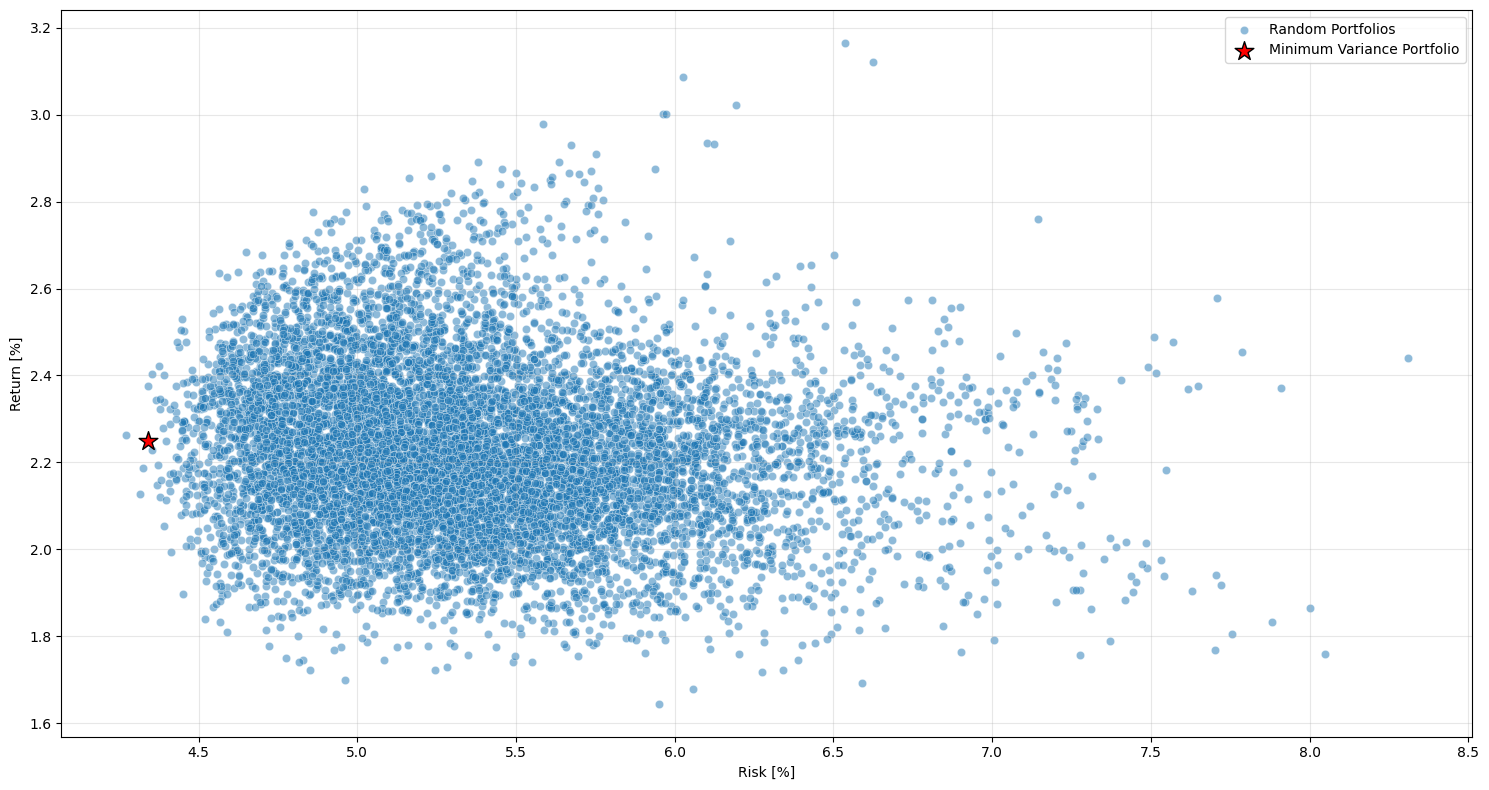

In [37]:
plt.figure(figsize=(15,8))
sns.scatterplot(x=summary_portfolio["Risk"]*100,y=summary_portfolio["Return"]*100,label="Random Portfolios",alpha=0.5)
plt.scatter(risk_portfolio_min_var*100,return_min_var*100,label="Minimum Variance Portfolio",color="red",marker="*",s=200,edgecolors="black")
plt.xlabel("Risk [%]")
plt.ylabel("Return [%]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

One might wonder why the "minimum variance portfolio" appears to not have the minimum risk when looking at the graph. The explanation is simple: The constraints imposed on the optimization algorithm affect the solution. If the minimum stake for each stock were not restricted, the result would have not been contrary to expectations, as shown below:

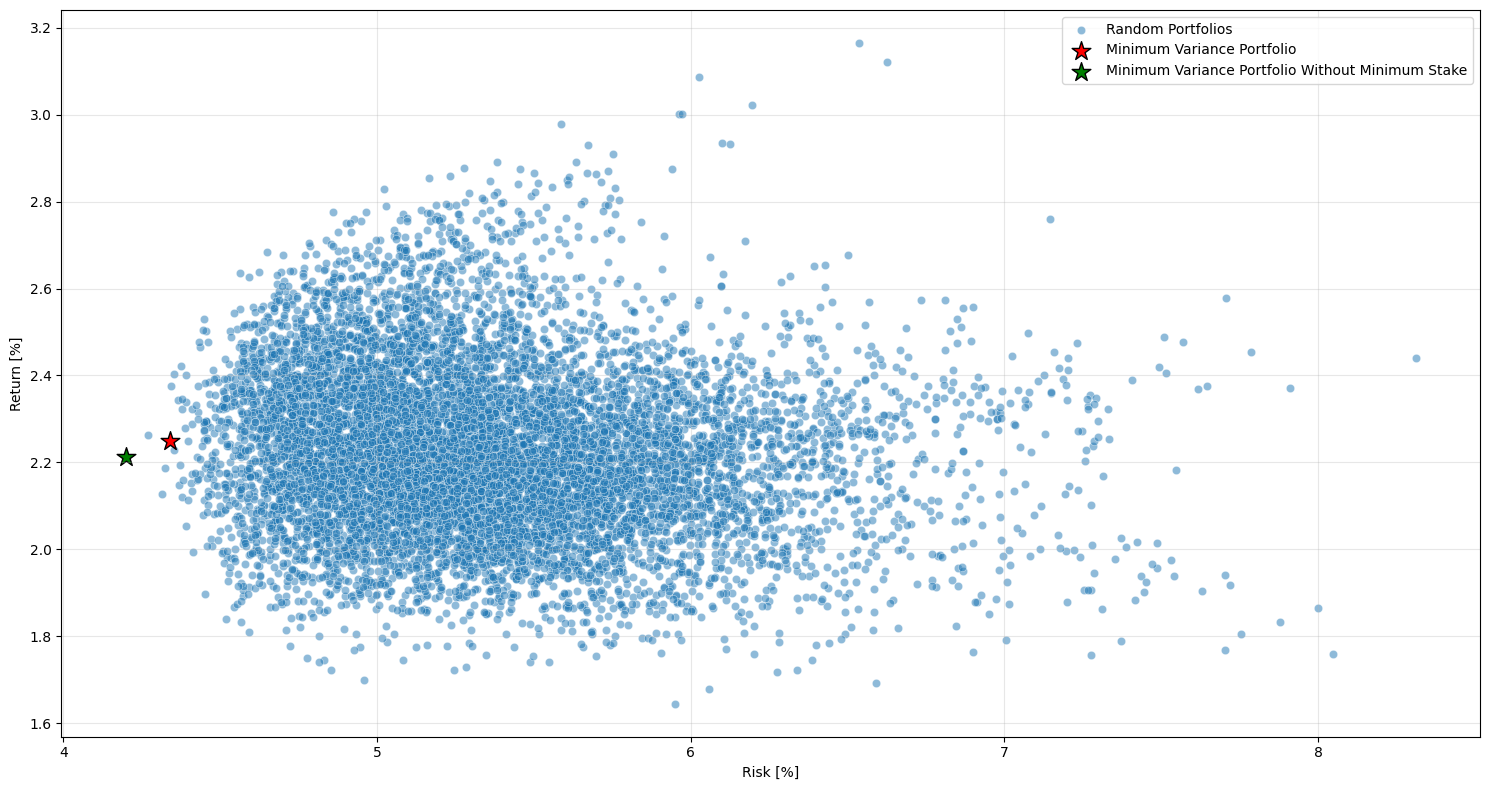

In [38]:
plt.figure(figsize=(15,8))
sns.scatterplot(x=summary_portfolio["Risk"]*100,y=summary_portfolio["Return"]*100,label="Random Portfolios",alpha=0.5)
plt.scatter(risk_portfolio_min_var*100,return_min_var*100,label="Minimum Variance Portfolio",color="red",marker="*",s=200,edgecolors="black")
plt.scatter(risk_portfolio_min_var_no_restrictions*100,return_min_var_no_restrictions*100,label="Minimum Variance Portfolio Without Minimum Stake",color="green",marker="*",s=200,edgecolors="black")
plt.xlabel("Risk [%]")
plt.ylabel("Return [%]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Assets $\beta$

To calculate the $\beta$ of an asset, the covariance between the asset and the market, and the variance of the market need to be known. In this case, the market will be represented by the S&P 500 index. This data has already been calculated; we simply need to use it as shown below.

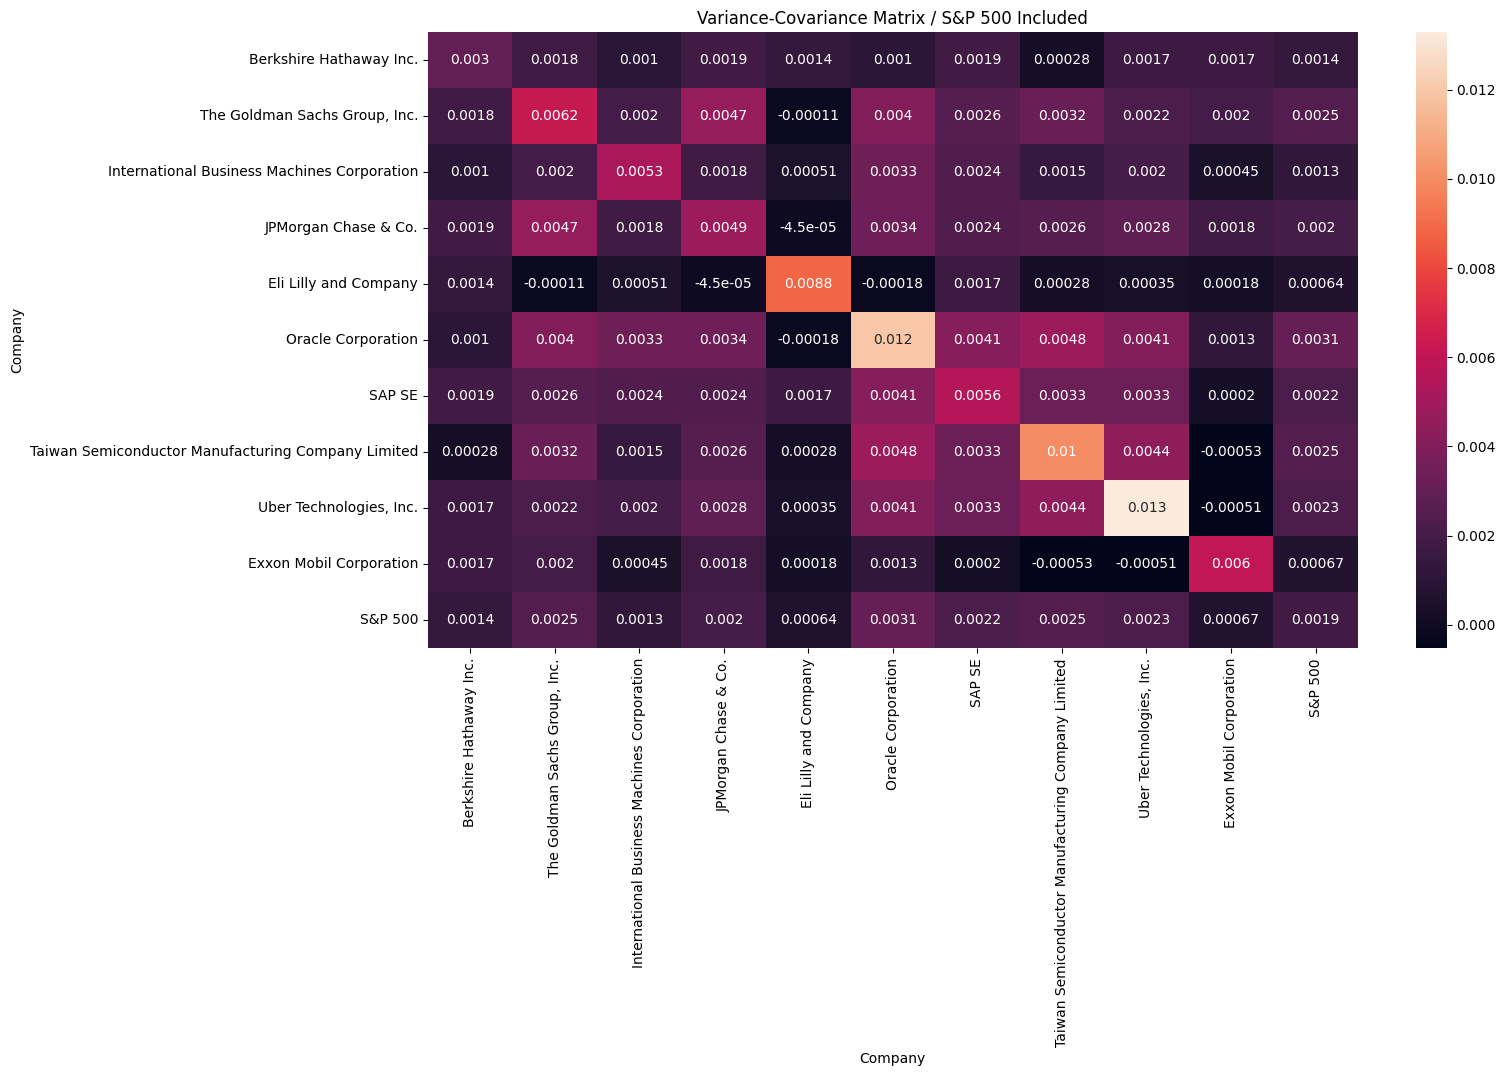

In [39]:
plt.figure(figsize=(15,8))
sns.heatmap(cov_matrix_generalized,annot=True)
plt.title("Variance-Covariance Matrix / S&P 500 Included")
plt.show()

In [40]:
print("Assets' Beta")
for stock in cov_matrix.columns:
    beta = cov_matrix_generalized.loc[stock, "S&P 500"] / sp_500_stats["Variance"]
    print(f"{stock:-<55} β = {beta:.4f}")

Assets' Beta
Berkshire Hathaway Inc.-------------------------------- β = 0.7223
The Goldman Sachs Group, Inc.-------------------------- β = 1.3100
International Business Machines Corporation------------ β = 0.6731
JPMorgan Chase & Co.----------------------------------- β = 1.0761
Eli Lilly and Company---------------------------------- β = 0.3399
Oracle Corporation------------------------------------- β = 1.6505
SAP SE------------------------------------------------- β = 1.1707
Taiwan Semiconductor Manufacturing Company Limited----- β = 1.3005
Uber Technologies, Inc.-------------------------------- β = 1.1960
Exxon Mobil Corporation-------------------------------- β = 0.3561


It is observed that the $\beta$ corresponding to each stock in the portfolio are positive, which indicates that all the stocks that make up the portfolio move in the same direction as the market, although some with greater sensitivity than others.

# 9. Construction of the CML and Discovery of the Tangent Portfolio

The risk-free rate is determined using the **TNX** index, which provides information on the yield of the 10-year US Treasury bond. The reference value is the closing price on the last day of the period considered for the analysis of the previously analyzed stocks.

In [41]:
bond = yf.download("^TNX", start="2025-11-14", end="2025-11-15", auto_adjust=True)["Close"]
bond

[*********************100%***********************]  1 of 1 completed

Ticker,^TNX
Date,
2025-11-14,4.148


The rates provided by the index are annual effective rates. Therefore, to make it comparable with the portfolio performance analysis found previously, it must be converted to a monthly effective rate, as shown below:
$$i_{EM} = (1+i_{EA})^{\frac{1}{12}} - 1$$

In [42]:
Rf = (1 + bond.iloc[0,0]/100)**(1/12) - 1
print(f"Risk-free Rate: {Rf*100:.6f} [%]")

Risk-free Rate: 0.339264 [%]


To find the maximum slope and the tangent line to the efficient frontier, or in other words, the capital market line (CML), the maximum Sharpe ratio must be found:
$$Sharpe\;Ratio = \frac{R_i - R_F}{\sigma_i}$$
We have another optimization problem, this time seeking to maximize a function (or equivalently, minimize its negative), taking into account the risk-free rate $(R_F)$, the expected portfolio return $(R_i)$, and the portfolio's risk $(\sigma_i)$.
To find the solution, we will again use the optimize module from the scipy library, as shown below.

In [43]:
# Objective Function: Negative Sharpe Ratio (Maximization)
def negative_sharpe_ratio(weights, returns_vector, covariance_matrix, risk_free_yield):
    portfolio_return = weights @ returns_vector
    portfolio_risk = np.sqrt(weights.transpose() @ covariance_matrix @ weights)
    sharpe_ratio = (portfolio_return - risk_free_yield) / portfolio_risk
    return -sharpe_ratio  # Negative because the module finds minima

# Limits and Restrictions
restrictions = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Weights' sum = 1
tangency_limits_no_restrictions = tuple((0, 1) for _ in range(len(cov_matrix)))  # Weights between 0% and 100%
tangency_limits = tuple((0.05, 1) for _ in range(len(cov_matrix)))  # Weights between 5% and 100%

# Initial Conditions
w0 = np.ones(len(cov_matrix)) / len(cov_matrix)

# Optimization to Find Tangent Portfolio
tangency_result = optimize.minimize(
    negative_sharpe_ratio,
    w0,
    args=(average_vector, cov_matrix, Rf),
    method='SLSQP',
    bounds=tangency_limits,
    constraints=restrictions,
    options={'ftol': 1e-16}
)
tangency_result_no_restrictions = optimize.minimize(
    negative_sharpe_ratio,
    w0,
    args=(average_vector, cov_matrix, Rf),
    method='SLSQP',
    bounds=tangency_limits_no_restrictions,
    constraints=restrictions,
    options={'ftol': 1e-16}
)

# Tangent Portfolio Weights
weights_tangency = pd.Series(tangency_result.x, index=df_r.drop(columns="S&P 500").columns)
max_sharpe_ratio = -tangency_result.fun

# Tangent Portfolio Return and Risk
return_tangency = weights_tangency @ average_vector
risk_tangency = np.sqrt(weights_tangency.transpose() @ cov_matrix @ weights_tangency)

# Tangent Portfolio Weights - No Restrictions
weights_tangency_no_restrictions = pd.Series(tangency_result_no_restrictions.x, index=df_r.drop(columns="S&P 500").columns)
max_sharpe_ratio_no_restrictions = -tangency_result_no_restrictions.fun

# Tangent Portfolio Return and Risk - No Restrictions
return_tangency_no_restrictions = weights_tangency_no_restrictions @ average_vector
risk_tangency_no_restrictions = np.sqrt(weights_tangency_no_restrictions.transpose() @ cov_matrix @ weights_tangency_no_restrictions)

print(f"Optimized Weights' Vector\n{weights_tangency}")
print(f"Weights' Sum: {weights_tangency.sum()}\n")
print(f"Expected Return: {return_tangency*100:.6f} [%]")
print(f"Risk: {risk_tangency*100:.6f} [%]")
print(f"Maximum Sharpe Ratio: {max_sharpe_ratio:.6f}\n")

print(f"Optimized Weights' Vector - No Restrictions\n{weights_tangency_no_restrictions}")
print(f"Weights' Sum - No Restrictions: {weights_tangency_no_restrictions.sum()}\n")
print(f"Expected Return - No Restrictions: {return_tangency_no_restrictions*100:.6f} [%]")
print(f"Risk - No Restrictions: {risk_tangency_no_restrictions*100:.6f} [%]")
print(f"Maximum Sharpe Ratio - No Restrictions: {max_sharpe_ratio_no_restrictions:.6f}\n")


Optimized Weights' Vector
Company
Berkshire Hathaway Inc.                               0.050000
The Goldman Sachs Group, Inc.                         0.050000
International Business Machines Corporation           0.114729
JPMorgan Chase & Co.                                  0.050000
Eli Lilly and Company                                 0.304802
Oracle Corporation                                    0.050000
SAP SE                                                0.050000
Taiwan Semiconductor Manufacturing Company Limited    0.058672
Uber Technologies, Inc.                               0.050000
Exxon Mobil Corporation                               0.221797
dtype: float64
Weights' Sum: 1.0

Expected Return: 2.630393 [%]
Risk: 4.615551 [%]
Maximum Sharpe Ratio: 0.496393

Optimized Weights' Vector - No Restrictions
Company
Berkshire Hathaway Inc.                               6.418877e-18
The Goldman Sachs Group, Inc.                         1.037896e-01
International Business Machines Cor

# 10. Final Chart

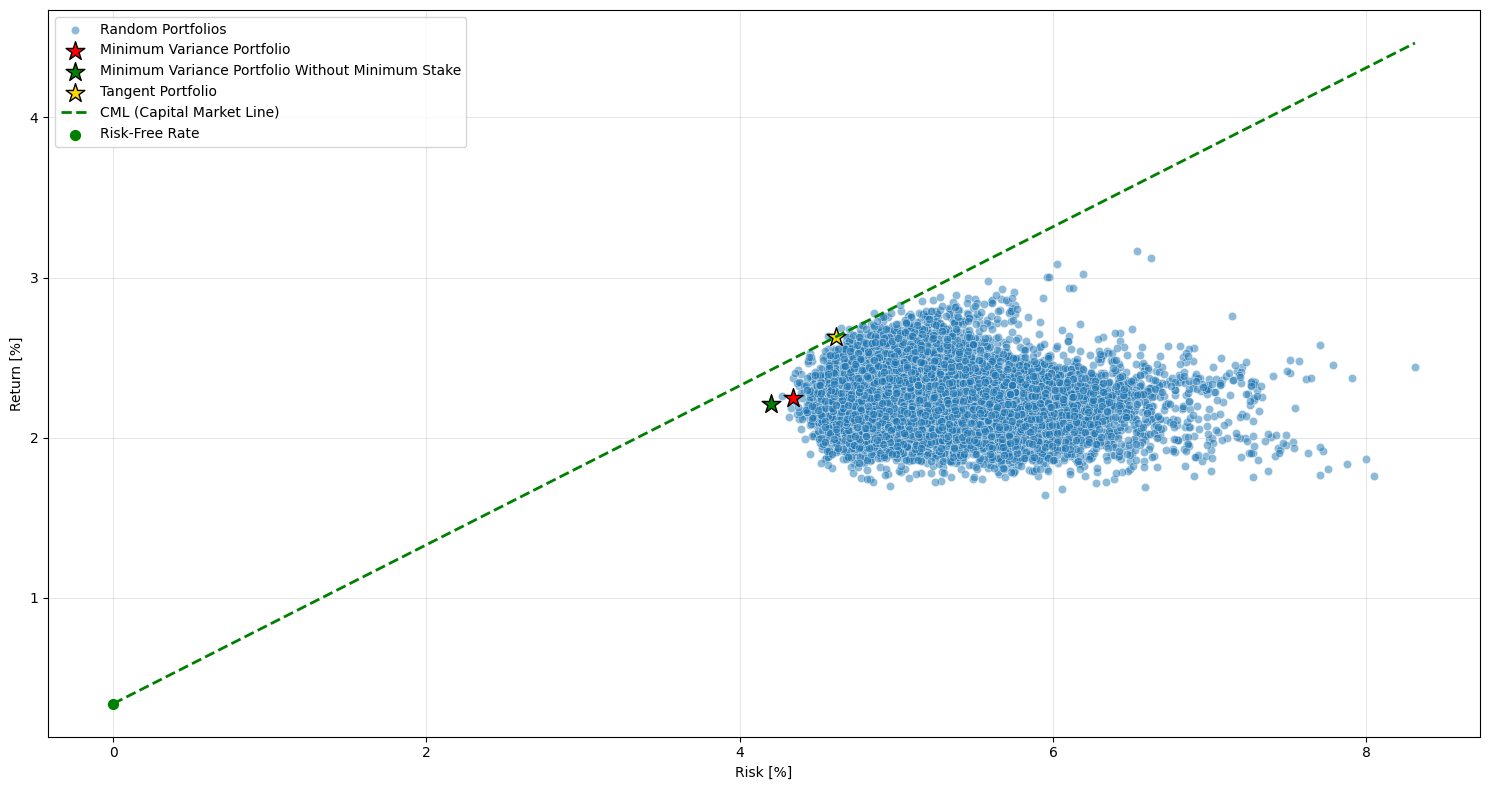

In [44]:
x_points = np.linspace(0, (summary_portfolio["Risk"]*100).max(), 100)
cml = Rf*100 + max_sharpe_ratio * x_points
plt.figure(figsize=(15,8))
sns.scatterplot(x=summary_portfolio["Risk"]*100,y=summary_portfolio["Return"]*100,label="Random Portfolios",alpha=0.5)
plt.scatter(risk_portfolio_min_var*100,return_min_var*100,label="Minimum Variance Portfolio",color="red",marker="*",s=200,edgecolors="black")
plt.scatter(risk_portfolio_min_var_no_restrictions*100,return_min_var_no_restrictions*100,label="Minimum Variance Portfolio Without Minimum Stake",color="green",marker="*",s=200,edgecolors="black")
plt.scatter(risk_tangency*100, return_tangency*100,label="Tangent Portfolio",color="gold", marker="*",s=200,edgecolors="black")
plt.plot(x_points,cml, 'g--',linewidth=2,label="CML (Capital Market Line)")
plt.scatter(0, Rf*100,color='green',marker='o',s=50,label="Risk-Free Rate",zorder=5)
plt.xlabel("Risk [%]")
plt.ylabel("Return [%]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We again observe that the result is affected by the minimum participation constraint imposed by the optimization algorithm. The result for when this constraint is not imposed is shown below.

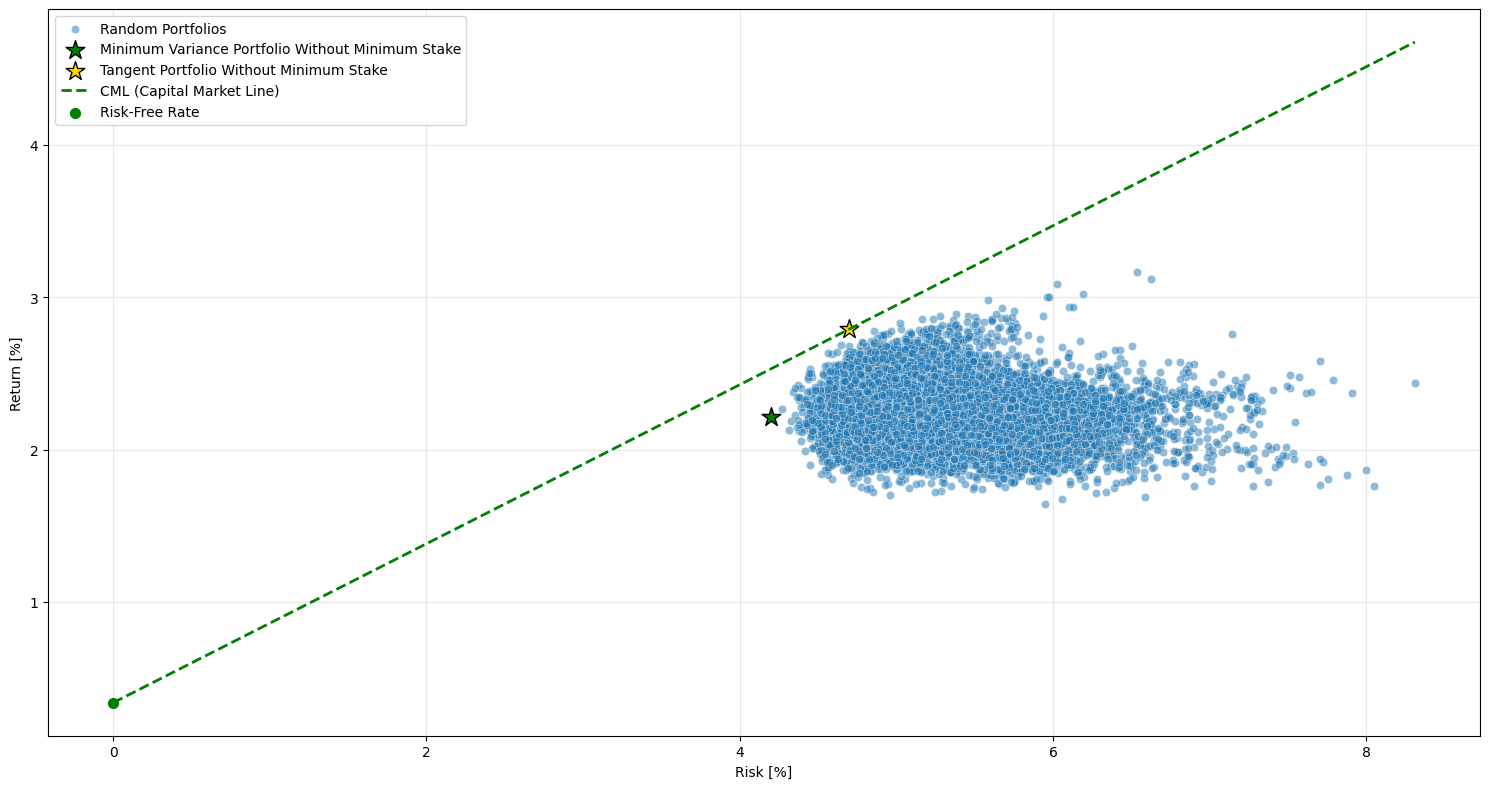

In [45]:
x_points = np.linspace(0, (summary_portfolio["Risk"]*100).max(), 100)
cml = Rf*100 + max_sharpe_ratio_no_restrictions * x_points
plt.figure(figsize=(15,8))
sns.scatterplot(x=summary_portfolio["Risk"]*100,y=summary_portfolio["Return"]*100,label="Random Portfolios",alpha=0.5)
plt.scatter(risk_portfolio_min_var_no_restrictions*100,return_min_var_no_restrictions*100,label="Minimum Variance Portfolio Without Minimum Stake",color="green",marker="*",s=200,edgecolors="black")
plt.scatter(risk_tangency_no_restrictions*100, return_tangency_no_restrictions*100,label="Tangent Portfolio Without Minimum Stake",color="gold", marker="*",s=200,edgecolors="black")
plt.plot(x_points,cml, 'g--',linewidth=2,label="CML (Capital Market Line)")
plt.scatter(0, Rf*100,color='green',marker='o',s=50,label="Risk-Free Rate",zorder=5)
plt.xlabel("Risk [%]")
plt.ylabel("Return [%]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()